In [101]:
import pandas as pd
# check installed version
import pycaret
pycaret.__version__

'3.3.2'

In [102]:
from IPython.display import HTML, display
display(HTML("""
<style>
/* Jupyter 출력 영역 중심으로 제한 */
.jp-RenderedHTMLCommon .dataframe td,
.jp-RenderedHTMLCommon .dataframe th {
  color: #111 !important;
  background-color: #fff !important;
}
</style>
"""))
pd.set_option("display.max_columns", None) 

In [103]:
from pycaret.datasets import get_data
dataset_list = get_data('index')
dataset_list

,Dataset,Data Types,Default Task,Target Variable 1,Target Variable 2,# Instances,# Attributes,Missing Values
0,anomaly,Multivariate,Anomaly Detection,NaN,NaN,1000,10,N
1,france,Multivariate,Association Rule Mining,InvoiceNo,Description,8557,8,N
2,germany,Multivariate,Association Rule Mining,InvoiceNo,Description,9495,8,N
3,bank,Multivariate,Classification (Binary),deposit,NaN,45211,17,N
4,blood,Multivariate,Classification (Binary),Class,NaN,748,5,N
5,cancer,Multivariate,Classification (Binary),Class,NaN,683,10,N
6,credit,Multivariate,Classification (Binary),default,NaN,24000,24,N
7,diabetes,Multivariate,Classification (Binary),Class variable,NaN,768,9,N
8,electrical_grid,Multivariate,Classification (Binary),stabf,NaN,10000,14,N
9,employee,Multivariate,Classification (Binary),left,NaN,14999,10,N


,Dataset,Data Types,Default Task,Target Variable 1,Target Variable 2,# Instances,# Attributes,Missing Values
0,anomaly,Multivariate,Anomaly Detection,NaN,NaN,1000,10,N
1,france,Multivariate,Association Rule Mining,InvoiceNo,Description,8557,8,N
2,germany,Multivariate,Association Rule Mining,InvoiceNo,Description,9495,8,N
3,bank,Multivariate,Classification (Binary),deposit,NaN,45211,17,N
4,blood,Multivariate,Classification (Binary),Class,NaN,748,5,N
5,cancer,Multivariate,Classification (Binary),Class,NaN,683,10,N
6,credit,Multivariate,Classification (Binary),default,NaN,24000,24,N
7,diabetes,Multivariate,Classification (Binary),Class variable,NaN,768,9,N
8,electrical_grid,Multivariate,Classification (Binary),stabf,NaN,10000,14,N
9,employee,Multivariate,Classification (Binary),left,NaN,14999,10,N


In [21]:
# loading sample dataset from pycaret dataset module
from pycaret.datasets import get_data
data = get_data('diabetes')

,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years),Class variable
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [22]:
data.describe()

,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years),Class variable
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [23]:
data.isna().sum()

Number of times pregnant                                                    0
Plasma glucose concentration a 2 hours in an oral glucose tolerance test    0
Diastolic blood pressure (mm Hg)                                            0
Triceps skin fold thickness (mm)                                            0
2-Hour serum insulin (mu U/ml)                                              0
Body mass index (weight in kg/(height in m)^2)                              0
Diabetes pedigree function                                                  0
Age (years)                                                                 0
Class variable                                                              0
dtype: int64

In [24]:
# import pycaret classification and init setup
from pycaret.classification import *
s = setup(data, target = 'Class variable', html=False,session_id = 123)

                    Description             Value
0                    Session id               123
1                        Target    Class variable
2                   Target type            Binary
3           Original data shape          (768, 9)
4        Transformed data shape          (768, 9)
5   Transformed train set shape          (537, 9)
6    Transformed test set shape          (231, 9)
7              Numeric features                 8
8                    Preprocess              True
9               Imputation type            simple
10           Numeric imputation              mean
11       Categorical imputation              mode
12               Fold Generator   StratifiedKFold
13                  Fold Number                10
14                     CPU Jobs                -1
15                      Use GPU             False
16               Log Experiment             False
17              Experiment Name  clf-default-name
18                          USI              e9af


Once the setup has been successfully executed it shows the information grid containing experiment level information.

- **Session id:**  A pseudo-random number distributed as a seed in all functions for later reproducibility. If no `session_id` is passed, a random number is automatically generated that is distributed to all functions.<br/>
<br/>
- **Target type:**  Binary, Multiclass, or Regression. The Target type is automatically detected. <br/>
<br/>
- **Label Encoding:**  When the Target variable is of type string (i.e. 'Yes' or 'No') instead of 1 or 0, it automatically encodes the label into 1 and 0 and displays the mapping (0 : No, 1 : Yes) for reference. In this tutorial, no label encoding is required since the target variable is of numeric type. <br/>
<br/>
- **Original data shape:**  Shape of the original data prior to any transformations. <br/>
<br/>
- **Transformed train set shape :**  Shape of transformed train set <br/>
<br/>
- **Transformed test set shape :**  Shape of transformed test set <br/>
<br/>
- **Numeric features :**  The number of features considered as numerical. <br/>
<br/>
- **Categorical features :**  The number of features considered as categorical. <br/>

PyCaret has two set of API's that you can work with. (1) Functional (as seen above) and (2) Object Oriented API.

With Object Oriented API instead of executing functions directly you will import a class and execute methods of class.

You can use any of the two method i.e. Functional or OOP and even switch back and forth between two set of API's. The choice of method will not impact the results and has been tested for consistency.

## Compare Models

This function trains and evaluates the performance of all the estimators available in the model library using cross-validation. The output of this function is a scoring grid with average cross-validated scores. Metrics evaluated during CV can be accessed using the `get_metrics` function. Custom metrics can be added or removed using `add_metric` and `remove_metric` function.

Kappa(코헨의 카파 계수)는 PyCaret 결과 표에서 Accuracy(정확도) 바로 옆에 위치하며, 모델의 예측이 단순히 우연히 맞은 것인지를 측정하는 지표입니다.
0 이하: 우연보다 못한 수준 (예측 의미 없음)
0.01 ~ 0.20: 약간의 일치 (Slight)
0.21 ~ 0.40: 어느 정도의 일치 (Fair)
0.41 ~ 0.60: 상당한 수준의 일치 (Moderate) - 보통 성능이 괜찮다고 보는 지점입니다.
0.61 ~ 0.80: 높은 수준의 일치 (Substantial)
0.81 ~ 1.00: 거의 완벽한 일치 (Almost Perfect)


MCC(Matthews Correlation Coefficient)는 모델의 예측 성능을 -1에서 +1 사이의 수치로 나타냅니다. 
혼동 행렬(Confusion Matrix)의 네 가지 요소(TP, TN, FP, FN)를 모두 고려하기 때문에, 특히 데이터 불균형이 심할 때 Accuracy(정확도)보다 훨씬 신뢰할 수 있는 지표입니다.
값에 따른 구체적인 해석은 다음과 같습니다.
+1.0 (완벽한 예측): 모델이 모든 정답과 오답을 완벽하게 맞춘 상태입니다.
0.0 (무작위 예측): 동전 던지기와 다를 바 없는 수준입니다. 모델이 데이터의 패턴을 전혀 학습하지 못했음을 의미합니다.
-1.0 (완벽한 불일치): 실제 값과 예측 값이 정반대인 상태입니다.
0.3 ~ 0.5: 보통 수준의 상관관계가 있다고 봅니다.
0.7 이상: 매우 강한 상관관계, 즉 매우 우수한 모델로 평가합니다.


Kappa vs MCC 요약
Kappa: 데이터의 클래스 분포(우연성)를 보정한 지표입니다.
MCC: 혼동 행렬의 네 요소를 더 균형 있게 반영하므로, 매우 극심한 불균형 데이터에서는 MCC가 조금 더 엄격하고 정확한 평가 지표로 권장됩니다.

In [25]:
# compare baseline models
best = compare_models(verbose=False)

res = pull()
display(
    res.style
      .set_properties(**{
          "color": "#111",
          "background-color": "#fff"
      })
)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 168, number of negative: 315
[LightGBM] [Info] Number of positive: 168, number of negative: 315
[LightGBM] [Info] Number of positive: 168, number of negative: 315
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002433 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002709 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 571[LightGBM] [Info] Total Bins 575

[LightGBM] [Info] Auto-choosing row-wise 

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.768900,0.804700,0.560200,0.720800,0.627900,0.464100,0.473600,0.020000
ridge,Ridge Classifier,0.767000,0.806000,0.549700,0.723500,0.622100,0.458100,0.469000,0.008000
lda,Linear Discriminant Analysis,0.767000,0.805500,0.555000,0.720200,0.624300,0.459400,0.469500,0.007000
rf,Random Forest Classifier,0.748500,0.791100,0.528400,0.681100,0.592400,0.415000,0.423800,0.049000
nb,Naive Bayes,0.742700,0.795500,0.570200,0.654300,0.604300,0.415600,0.421500,0.008000
catboost,CatBoost Classifier,0.741000,0.799300,0.527800,0.663000,0.585100,0.400500,0.407800,0.357000
gbc,Gradient Boosting Classifier,0.737300,0.790900,0.555000,0.644500,0.593100,0.401300,0.405900,0.035000
ada,Ada Boost Classifier,0.737200,0.779900,0.527500,0.658500,0.579600,0.392600,0.401700,0.023000
et,Extra Trees Classifier,0.729900,0.778800,0.496500,0.651600,0.559600,0.370600,0.380200,0.039000
qda,Quadratic Discriminant Analysis,0.728200,0.789400,0.528100,0.655800,0.573600,0.378500,0.391000,0.008000


## Analyze Model

You can use the `plot_model` function to analyzes the performance of a trained model on the test set. It may require re-training the model in certain cases.

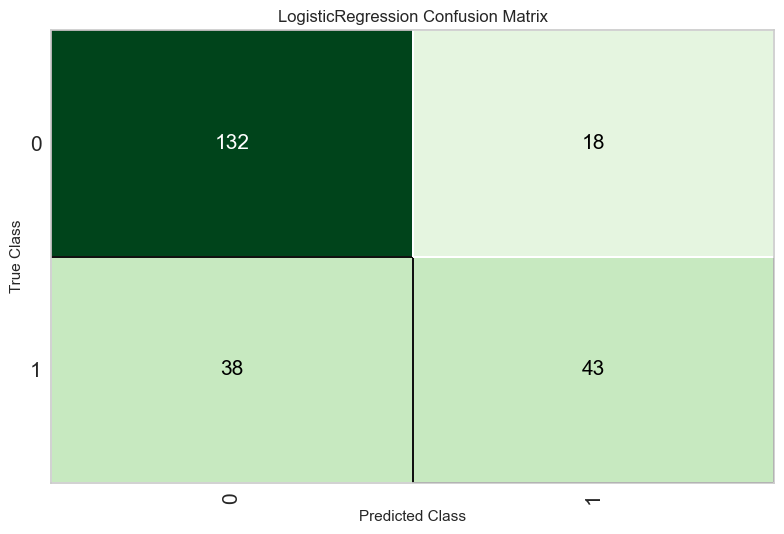

In [26]:
# plot confusion matrix
plot_model(best, plot = 'confusion_matrix')

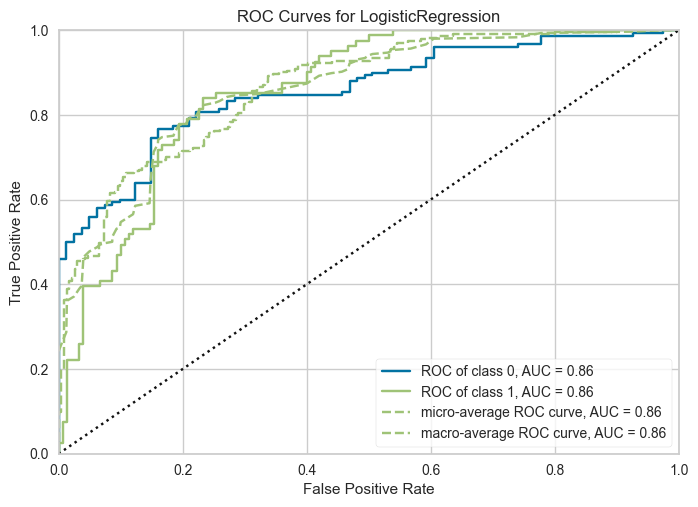

In [27]:
# plot AUC
plot_model(best, plot = 'auc')

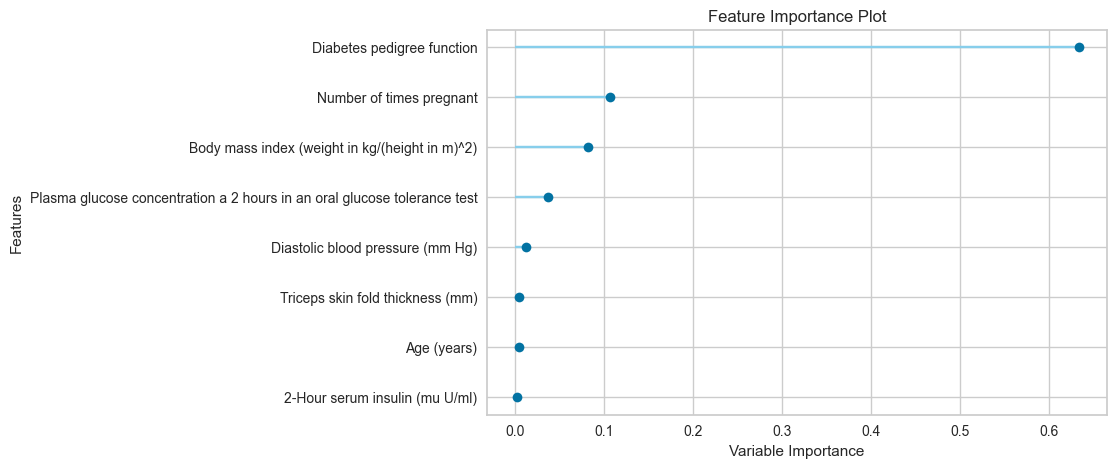

In [28]:
# plot feature importance
plot_model(best, plot = 'feature')

___

## Prediction
The `predict_model` function returns `prediction_label` and `prediction_score` (probability of the predicted class) as new columns in dataframe. When data is `None` (default), it uses the test set (created during the setup function) for scoring.

In [29]:
# predict on test set
holdout_pred = predict_model(best)

                 Model  Accuracy     AUC  Recall   Prec.      F1   Kappa  \
0  Logistic Regression    0.7576  0.8568  0.5309  0.7049  0.6056  0.4356   

      MCC  
0  0.4447  


In [30]:
# show predictions df
holdout_pred.head()

,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years),Class variable,prediction_label,prediction_score
552,6,114,88,0,0,27.799999,0.247,66,0,0,0.8037
438,1,97,70,15,0,18.200001,0.147,21,0,0,0.9648
149,2,90,70,17,0,27.299999,0.085,22,0,0,0.9394
373,2,105,58,40,94,34.900002,0.225,25,0,0,0.7999
36,11,138,76,0,0,33.200001,0.420,35,0,1,0.6393


The same function works for predicting the labels on unseen dataset. Let's create a copy of original data and drop the `Class variable`. We can then use the new data frame without labels for scoring.

In [31]:
# copy data and drop Class variable

new_data = data.copy()
new_data.drop('Class variable', axis=1, inplace=True)
new_data.head()

,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years)
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [32]:
# predict model on new_data
predictions = predict_model(best, data = new_data)
predictions.head()

,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years),prediction_label,prediction_score
0,6,148,72,35,0,33.599998,0.627,50,1,0.6940
1,1,85,66,29,0,26.600000,0.351,31,0,0.9419
2,8,183,64,0,0,23.299999,0.672,32,1,0.7976
3,1,89,66,23,94,28.100000,0.167,21,0,0.9454
4,0,137,40,35,168,43.099998,2.288,33,1,0.8394


## Save Model

Finally, you can save the entire pipeline on disk for later use, using pycaret's `save_model` function.

In [33]:
# save pipeline
save_model(best, 'my_first_pipeline')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['Number of times pregnant',
                                              'Plasma glucose concentration a 2 '
                                              'hours in an oral glucose '
                                              'tolerance test',
                                              'Diastolic blood pressure (mm Hg)',
                                              'Triceps skin fold thickness (mm)',
                                              '2-Hour serum insulin (mu U/ml)',
                                              'Body mass index (weight in '
                                              'kg/(height in m)^2)',
                                              'Diabetes pedigre...
                  TransformerWrapper(exclude=None, include=None,
                                     transformer=CleanC

In [34]:
# load pipeline
loaded_best_pipeline = load_model('my_first_pipeline')
loaded_best_pipeline

Transformation Pipeline and Model Successfully Loaded


Pipeline(memory=FastMemory(location=/var/folders/6r/ryg35lj50jg7mx0b5gtcd61c0000gn/T/joblib),
         steps=[('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['Number of times pregnant',
                                             'Plasma glucose concentration a 2 '
                                             'hours in an oral glucose '
                                             'tolerance test',
                                             'Diastolic blood pressure (mm Hg)',
                                             'Triceps skin fold thickness (mm)',
                                             '2-Hour serum insulin (mu U/ml)',
                                             'Body...
                 TransformerWrapper(exclude=None, include=None,
                                    transformer=CleanColumnNames(match='[\\]\\[\\,\\{\\}\\"\\:]+'))),
                ('trained_model',
                 LogisticRegression(C=1.0, class_weight=None, dual=False,
                                    fit_intercept=True, intercept_scaling=1,
                                    l1_ratio=None, max_iter=1000,
                                    multi_class='auto', n_jobs=None,
                                    penalty='l2', random_state=123,
                                    solver='lbfgs', tol=0.0001, verbose=0,
                                    warm_start=False))],
         verbose=False)

# 👇 Detailed function-by-function overview

## ✅ Setup
This function initializes the experiment in PyCaret and creates the transformation pipeline based on all the parameters passed in the function. Setup function must be called before executing any other function. It takes two required parameters: `data` and `target`. All the other parameters are optional and are used for configuring data preprocessing pipeline.

In [35]:
# init setup function
s = setup(data, target = 'Class variable', session_id = 123)

,Description,Value
0,Session id,123
1,Target,Class variable
2,Target type,Binary
3,Original data shape,"(768, 9)"
4,Transformed data shape,"(768, 9)"
5,Transformed train set shape,"(537, 9)"
6,Transformed test set shape,"(231, 9)"
7,Numeric features,8
8,Preprocess,True
9,Imputation type,simple


To access all the variables created by the setup function such as transformed dataset, random_state, etc. you can use `get_config` method.

In [36]:
# check all available config
get_config()

{'USI',
 'X',
 'X_test',
 'X_test_transformed',
 'X_train',
 'X_train_transformed',
 'X_transformed',
 '_available_plots',
 '_ml_usecase',
 'data',
 'dataset',
 'dataset_transformed',
 'exp_id',
 'exp_name_log',
 'fix_imbalance',
 'fold_generator',
 'fold_groups_param',
 'fold_shuffle_param',
 'gpu_n_jobs_param',
 'gpu_param',
 'html_param',
 'idx',
 'is_multiclass',
 'log_plots_param',
 'logging_param',
 'memory',
 'n_jobs_param',
 'pipeline',
 'seed',
 'target_param',
 'test',
 'test_transformed',
 'train',
 'train_transformed',
 'variable_and_property_keys',
 'variables',
 'y',
 'y_test',
 'y_test_transformed',
 'y_train',
 'y_train_transformed',
 'y_transformed'}

In [37]:
get_config('X_train')

,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years)
323,13,152,90,33,29,26.799999,0.731,43
448,0,104,64,37,64,33.599998,0.510,22
84,5,137,108,0,0,48.799999,0.227,37
529,0,111,65,0,0,24.600000,0.660,31
329,6,105,70,32,68,30.799999,0.122,37
...,...,...,...,...,...,...,...,...
327,10,179,70,0,0,35.099998,0.200,37
57,0,100,88,60,110,46.799999,0.962,31
112,1,89,76,34,37,31.200001,0.192,23
751,1,121,78,39,74,39.000000,0.261,28


In [38]:
# lets access X_train_transformed
get_config('X_train_transformed')

,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years)
323,13.0,152.0,90.0,33.0,29.0,26.799999,0.731,43.0
448,0.0,104.0,64.0,37.0,64.0,33.599998,0.510,22.0
84,5.0,137.0,108.0,0.0,0.0,48.799999,0.227,37.0
529,0.0,111.0,65.0,0.0,0.0,24.600000,0.660,31.0
329,6.0,105.0,70.0,32.0,68.0,30.799999,0.122,37.0
...,...,...,...,...,...,...,...,...
327,10.0,179.0,70.0,0.0,0.0,35.099998,0.200,37.0
57,0.0,100.0,88.0,60.0,110.0,46.799999,0.962,31.0
112,1.0,89.0,76.0,34.0,37.0,31.200001,0.192,23.0
751,1.0,121.0,78.0,39.0,74.0,39.000000,0.261,28.0


In [39]:
# another example: let's access seed
print("The current seed is: {}".format(get_config('seed')))

# now lets change it using set_config
set_config('seed', 786)
print("The new seed is: {}".format(get_config('seed')))

The current seed is: 123
The new seed is: 786


In [40]:
# init setup with normalize = True

s = setup(data, target = 'Class variable', session_id = 123,
          normalize = True, normalize_method = 'minmax')

,Description,Value
0,Session id,123
1,Target,Class variable
2,Target type,Binary
3,Original data shape,"(768, 9)"
4,Transformed data shape,"(768, 9)"
5,Transformed train set shape,"(537, 9)"
6,Transformed test set shape,"(231, 9)"
7,Numeric features,8
8,Preprocess,True
9,Imputation type,simple


<Axes: >

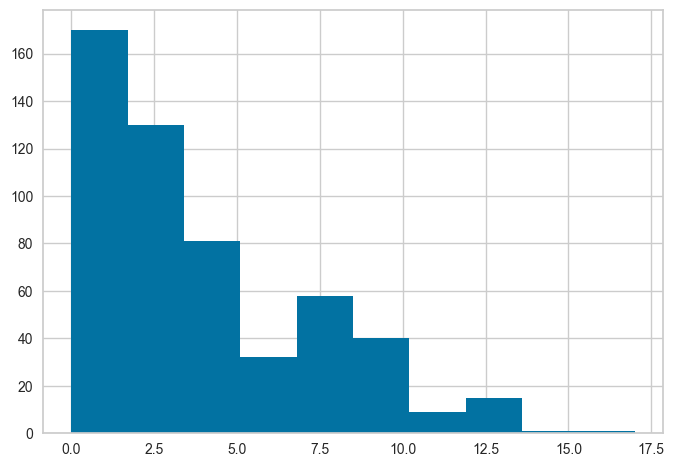

In [41]:
get_config('X_train')['Number of times pregnant'].hist()

<Axes: >

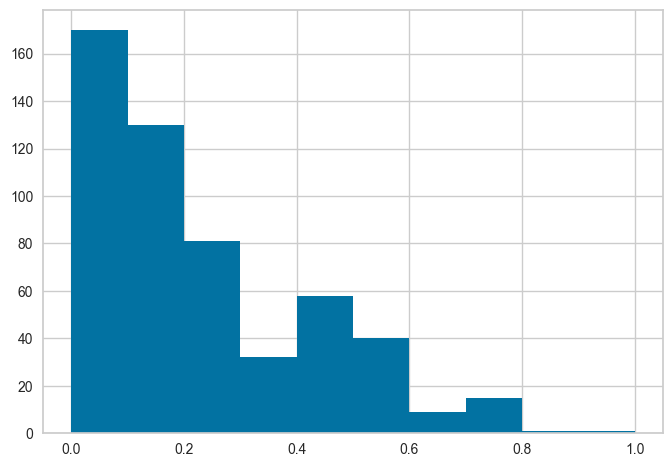

In [42]:
# lets check the X_train_transformed to see effect of params passed
get_config('X_train_transformed')['Number of times pregnant'].hist()

Notice that all the values are between 0 and 1 - that is because we passed `normalize=True` in the `setup` function. If you don't remember how it compares to actual data, no problem - we can also access non-transformed values using `get_config` and then compare. See below and notice the range of values on x-axis and compare it with histogram above.

<Axes: >

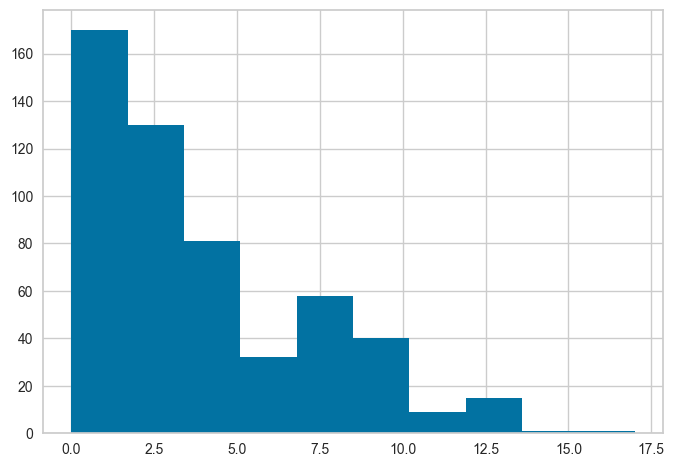

In [43]:
get_config('X_train')['Number of times pregnant'].hist()

<Axes: >

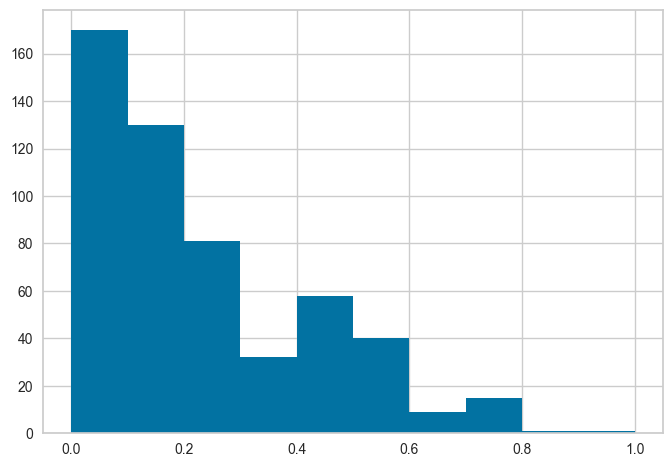

In [44]:
get_config('X_train_transformed')['Number of times pregnant'].hist()

___

## ✅ Compare Models
This function trains and evaluates the performance of all estimators available in the model library using cross-validation. The output of this function is a scoring grid with average cross-validated scores. Metrics evaluated during CV can be accessed using the `get_metrics` function. Custom metrics can be added or removed using `add_metric` and `remove_metric` function.

In [45]:
best = compare_models(verbose=False)
res = pull()
display(
    res.style
      .set_properties(**{
          "color": "#111",
          "background-color": "#fff"
      })
)

# w/o minmax normalization
# Logistic Regression	    0.768900	0.804700	0.560200	0.720800	0.627900	0.464100	0.473600	0.037000
# ridge	Ridge Classifier	0.767000	0.806000	0.549700	0.723500	0.622100	0.458100	0.469000	0.008000

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 168, number of negative: 315
[LightGBM] [Info] Number of positive: 168, number of negative: 315
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001714 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 572
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001855 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 569
[LightGBM] [Info] Number of data points in the train set: 483, number of used features: 8
[LightGBM] [Info] Number of data points in the train set: 483, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.347826 -> initscore=-0.628609
[LightGBM] [Info] Start training from score -0.628609
[L

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.770800,0.807100,0.539200,0.735300,0.620300,0.461800,0.474400,0.008000
lr,Logistic Regression,0.768900,0.807100,0.495900,0.761400,0.596800,0.445300,0.467300,0.043000
lda,Linear Discriminant Analysis,0.767000,0.805500,0.555000,0.720200,0.624300,0.459400,0.469500,0.007000
svm,SVM - Linear Kernel,0.752100,0.800500,0.507000,0.736300,0.579600,0.415400,0.439800,0.017000
rf,Random Forest Classifier,0.748500,0.791700,0.533600,0.678400,0.594600,0.416400,0.424500,0.064000
nb,Naive Bayes,0.742700,0.795700,0.570200,0.654300,0.604300,0.415600,0.421500,0.007000
catboost,CatBoost Classifier,0.741000,0.799400,0.527800,0.663000,0.585100,0.400500,0.407800,0.269000
gbc,Gradient Boosting Classifier,0.737300,0.790900,0.555000,0.644500,0.593100,0.401300,0.405900,0.035000
ada,Ada Boost Classifier,0.737200,0.779900,0.527500,0.658500,0.579600,0.392600,0.401700,0.023000
et,Extra Trees Classifier,0.729900,0.778800,0.496500,0.651600,0.559600,0.370600,0.380200,0.037000


`compare_models` by default uses all the estimators in model library (all except models with `Turbo=False`) . To see all available models you can use the function `models()`

In [46]:
# check available models
models()

,Name,Reference,Turbo
ID,,,
lr,Logistic Regression,sklearn.linear_model._logistic.LogisticRegression,True
knn,K Neighbors Classifier,sklearn.neighbors._classification.KNeighborsCl...,True
nb,Naive Bayes,sklearn.naive_bayes.GaussianNB,True
dt,Decision Tree Classifier,sklearn.tree._classes.DecisionTreeClassifier,True
svm,SVM - Linear Kernel,sklearn.linear_model._stochastic_gradient.SGDC...,True
rbfsvm,SVM - Radial Kernel,sklearn.svm._classes.SVC,False
gpc,Gaussian Process Classifier,sklearn.gaussian_process._gpc.GaussianProcessC...,False
mlp,MLP Classifier,sklearn.neural_network._multilayer_perceptron....,False
ridge,Ridge Classifier,sklearn.linear_model._ridge.RidgeClassifier,True


You can use the `include` and `exclude` parameter in the `compare_models` to train only select model or exclude specific models from training by passing the model id's in `exclude` parameter.

In [47]:
compare_tree_models = compare_models(include = ['dt', 'rf', 'et', 'gbc', 'xgboost', 'lightgbm', 'catboost'],verbose=False)
res = pull()
display(
    res.style
      .set_properties(**{
          "color": "#111",
          "background-color": "#fff"
      })
)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 168, number of negative: 315
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000590 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 572
[LightGBM] [Info] Number of data points in the train set: 483, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.347826 -> initscore=-0.628609
[LightGBM] [Info] Start training from score -0.628609
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 168, number of negative: 315
[LightGBM] [Info] Number of positive: 168, number of negative: 315
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000922 seconds.
You can set `force_col_wise=true` to

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.748500,0.791700,0.533600,0.678400,0.594600,0.416400,0.424500,0.045000
catboost,CatBoost Classifier,0.741000,0.799400,0.527800,0.663000,0.585100,0.400500,0.407800,0.304000
gbc,Gradient Boosting Classifier,0.737300,0.790900,0.555000,0.644500,0.593100,0.401300,0.405900,0.060000
et,Extra Trees Classifier,0.729900,0.778800,0.496500,0.651600,0.559600,0.370600,0.380200,0.037000
lightgbm,Light Gradient Boosting Machine,0.711300,0.765300,0.518100,0.603600,0.553300,0.342700,0.347900,0.254000
dt,Decision Tree Classifier,0.694700,0.652600,0.513700,0.566500,0.534300,0.310300,0.313000,0.010000
xgboost,Extreme Gradient Boosting,0.692800,0.757100,0.507000,0.577900,0.533500,0.306800,0.313100,0.017000


In [48]:
compare_tree_models

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=100, n_jobs=-1,
                       oob_score=False, random_state=123, verbose=0,
                       warm_start=False)

The function above has return trained model object as an output. The scoring grid is only displayed and not returned. If you need access to the scoring grid you can use `pull` function to access the dataframe.

In [49]:
compare_tree_models_results = pull()
compare_tree_models_results

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.7485,0.7917,0.5336,0.6784,0.5946,0.4164,0.4245,0.045
catboost,CatBoost Classifier,0.7410,0.7994,0.5278,0.6630,0.5851,0.4005,0.4078,0.304
gbc,Gradient Boosting Classifier,0.7373,0.7909,0.5550,0.6445,0.5931,0.4013,0.4059,0.060
et,Extra Trees Classifier,0.7299,0.7788,0.4965,0.6516,0.5596,0.3706,0.3802,0.037
lightgbm,Light Gradient Boosting Machine,0.7113,0.7653,0.5181,0.6036,0.5533,0.3427,0.3479,0.254
dt,Decision Tree Classifier,0.6947,0.6526,0.5137,0.5665,0.5343,0.3103,0.3130,0.010
xgboost,Extreme Gradient Boosting,0.6928,0.7571,0.5070,0.5779,0.5335,0.3068,0.3131,0.017


By default `compare_models` return the single best performing model based on the metric defined in the `sort` parameter. Let's change our code to return 3 top models based on `Recall`.

In [50]:
best_recall_models_top3 = compare_models(sort = 'Recall', n_select = 3,verbose=False)
res = pull()
display(
    res.style
      .set_properties(**{
          "color": "#111",
          "background-color": "#fff"
      })
)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 168, number of negative: 315
[LightGBM] [Info] Number of positive: 168, number of negative: 315
[LightGBM] [Info] Number of positive: 168, number of negative: 315
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000918 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 569
[LightGBM] [Info] Number of data points in the train set: 483, number of used features: 8
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000846 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 573
[LightGBM] [Info] Number of data points in the train set: 483, number of used f

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
nb,Naive Bayes,0.742700,0.795700,0.570200,0.654300,0.604300,0.415600,0.421500,0.007000
gbc,Gradient Boosting Classifier,0.737300,0.790900,0.555000,0.644500,0.593100,0.401300,0.405900,0.037000
lda,Linear Discriminant Analysis,0.767000,0.805500,0.555000,0.720200,0.624300,0.459400,0.469500,0.006000
ridge,Ridge Classifier,0.770800,0.807100,0.539200,0.735300,0.620300,0.461800,0.474400,0.009000
rf,Random Forest Classifier,0.748500,0.791700,0.533600,0.678400,0.594600,0.416400,0.424500,0.060000
qda,Quadratic Discriminant Analysis,0.728200,0.789400,0.528100,0.655800,0.573600,0.378500,0.391000,0.008000
catboost,CatBoost Classifier,0.741000,0.799400,0.527800,0.663000,0.585100,0.400500,0.407800,0.260000
ada,Ada Boost Classifier,0.737200,0.779900,0.527500,0.658500,0.579600,0.392600,0.401700,0.031000
lightgbm,Light Gradient Boosting Machine,0.711300,0.765300,0.518100,0.603600,0.553300,0.342700,0.347900,0.250000
dt,Decision Tree Classifier,0.694700,0.652600,0.513700,0.566500,0.534300,0.310300,0.313000,0.007000


In [51]:
# list of top 3 models by Recall
best_recall_models_top3

[GaussianNB(priors=None, var_smoothing=1e-09),
 GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                            learning_rate=0.1, loss='log_loss', max_depth=3,
                            max_features=None, max_leaf_nodes=None,
                            min_impurity_decrease=0.0, min_samples_leaf=1,
                            min_samples_split=2, min_weight_fraction_leaf=0.0,
                            n_estimators=100, n_iter_no_change=None,
                            random_state=123, subsample=1.0, tol=0.0001,
                            validation_fraction=0.1, verbose=0,
                            warm_start=False),
 LinearDiscriminantAnalysis(covariance_estimator=None, n_components=None,
                            priors=None, shrinkage=None, solver='svd',
                            store_covariance=False, tol=0.0001)]

Some other parameters that you might find very useful in `compare_models` are:

- fold
- cross_validation
- budget_time
- errors
- probability_threshold
- parallel

You can check the docstring of the function for more info.

In [52]:
help(compare_models)

Help on function compare_models in module pycaret.classification.functional:

compare_models(include: Optional[List[Union[str, Any]]] = None, exclude: Optional[List[str]] = None, fold: Union[int, Any, NoneType] = None, round: int = 4, cross_validation: bool = True, sort: str = 'Accuracy', n_select: int = 1, budget_time: Optional[float] = None, turbo: bool = True, errors: str = 'ignore', fit_kwargs: Optional[dict] = None, groups: Union[str, Any, NoneType] = None, experiment_custom_tags: Optional[Dict[str, Any]] = None, probability_threshold: Optional[float] = None, engine: Optional[Dict[str, str]] = None, verbose: bool = True, parallel: Optional[pycaret.internal.parallel.parallel_backend.ParallelBackend] = None) -> Union[Any, List[Any]]
    This function trains and evaluates performance of all estimators available in the
    model library using cross validation. The output of this function is a score grid
    with average cross validated scores. Metrics evaluated during CV can be access

## ✅ Create Model
This function trains and evaluates the performance of a given estimator using cross-validation. The output of this function is a scoring grid with CV scores by fold. Metrics evaluated during CV can be accessed using the `get_metrics` function. Custom metrics can be added or removed using `add_metric` and `remove_metric` function. All the available models can be accessed using the models function.

In [53]:
# check all the available models
models()

# Name	Reference	Turbo ID			
# lr	Logistic Regression	sklearn.linear_model._logistic.LogisticRegression	True
# knn	K Neighbors Classifier	sklearn.neighbors._classification.KNeighborsCl...	True
# nb	Naive Bayes	sklearn.naive_bayes.GaussianNB	True
# dt	Decision Tree Classifier	sklearn.tree._classes.DecisionTreeClassifier	True
# svm	SVM - Linear Kernel	sklearn.linear_model._stochastic_gradient.SGDC...	True
# rbfsvm	SVM - Radial Kernel	sklearn.svm._classes.SVC	False
# gpc	Gaussian Process Classifier	sklearn.gaussian_process._gpc.GaussianProcessC...	False
# mlp	MLP Classifier	sklearn.neural_network._multilayer_perceptron....	False
# ridge	Ridge Classifier	sklearn.linear_model._ridge.RidgeClassifier	True
# rf	Random Forest Classifier	sklearn.ensemble._forest.RandomForestClassifier	True
# qda	Quadratic Discriminant Analysis	sklearn.discriminant_analysis.QuadraticDiscrim...	True
# ada	Ada Boost Classifier	sklearn.ensemble._weight_boosting.AdaBoostClas...	True
# gbc	Gradient Boosting Classifier	sklearn.ensemble._gb.GradientBoostingClassifier	True
# lda	Linear Discriminant Analysis	sklearn.discriminant_analysis.LinearDiscrimina...	True
# et	Extra Trees Classifier	sklearn.ensemble._forest.ExtraTreesClassifier	True
# xgboost	Extreme Gradient Boosting	xgboost.sklearn.XGBClassifier	True
# lightgbm	Light Gradient Boosting Machine	lightgbm.sklearn.LGBMClassifier	True
# catboost	CatBoost Classifier	catboost.core.CatBoostClassifier	True
# dummy	Dummy Classifier	sklearn.dummy.DummyClassifier	True


,Name,Reference,Turbo
ID,,,
lr,Logistic Regression,sklearn.linear_model._logistic.LogisticRegression,True
knn,K Neighbors Classifier,sklearn.neighbors._classification.KNeighborsCl...,True
nb,Naive Bayes,sklearn.naive_bayes.GaussianNB,True
dt,Decision Tree Classifier,sklearn.tree._classes.DecisionTreeClassifier,True
svm,SVM - Linear Kernel,sklearn.linear_model._stochastic_gradient.SGDC...,True
rbfsvm,SVM - Radial Kernel,sklearn.svm._classes.SVC,False
gpc,Gaussian Process Classifier,sklearn.gaussian_process._gpc.GaussianProcessC...,False
mlp,MLP Classifier,sklearn.neural_network._multilayer_perceptron....,False
ridge,Ridge Classifier,sklearn.linear_model._ridge.RidgeClassifier,True


In [54]:
# train logistic regression with default fold=10
lr = create_model('lr',verbose=False)
res = pull()
display(
    res.style
      .set_properties(**{
          "color": "#111",
          "background-color": "#fff"
      })
)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.814800,0.903800,0.578900,0.846200,0.687500,0.562400,0.582800
1,0.833300,0.798500,0.631600,0.857100,0.727300,0.611200,0.626000
2,0.851900,0.938300,0.631600,0.923100,0.750000,0.649900,0.673600
3,0.722200,0.775900,0.421100,0.666700,0.516100,0.335000,0.352400
4,0.833300,0.908300,0.578900,0.916700,0.709700,0.601000,0.632200
5,0.685200,0.673700,0.421100,0.571400,0.484800,0.265600,0.272000
6,0.722200,0.782000,0.473700,0.642900,0.545500,0.352000,0.360500
7,0.754700,0.846000,0.333300,0.857100,0.480000,0.357900,0.426300
8,0.735800,0.695200,0.444400,0.666700,0.533300,0.359200,0.373600


The function above has return trained model object as an output. The scoring grid is only displayed and not returned. If you need access to the scoring grid you can use `pull` function to access the dataframe.

In [55]:
lr_results = pull()
print(type(lr_results))
lr_results

<class 'pandas.core.frame.DataFrame'>


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8148,0.9038,0.5789,0.8462,0.6875,0.5624,0.5828
1,0.8333,0.7985,0.6316,0.8571,0.7273,0.6112,0.6260
2,0.8519,0.9383,0.6316,0.9231,0.7500,0.6499,0.6736
3,0.7222,0.7759,0.4211,0.6667,0.5161,0.3350,0.3524
4,0.8333,0.9083,0.5789,0.9167,0.7097,0.6010,0.6322
5,0.6852,0.6737,0.4211,0.5714,0.4848,0.2656,0.2720
6,0.7222,0.7820,0.4737,0.6429,0.5455,0.3520,0.3605
7,0.7547,0.8460,0.3333,0.8571,0.4800,0.3579,0.4263
8,0.7358,0.6952,0.4444,0.6667,0.5333,0.3592,0.3736


In [56]:
# train logistic regression with fold=3
lr = create_model('lr', fold=3,verbose=False)
res = pull()
display(
    res.style
      .set_properties(**{
          "color": "#111",
          "background-color": "#fff"
      })
)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.810100,0.852600,0.571400,0.837200,0.679200,0.551000,0.571300
1,0.748600,0.792100,0.500000,0.688900,0.579400,0.406500,0.417200
2,0.748600,0.780500,0.419400,0.742900,0.536100,0.381500,0.410800
Mean,0.769100,0.808400,0.496900,0.756300,0.598300,0.446400,0.466400
Std,0.029000,0.031600,0.062100,0.061300,0.059900,0.074700,0.074200


In [57]:
# train logistic regression with specific model parameters
# C (inverse regularization strength) 작은 양수로 작은값은 강한 제약을 줌
# l1_ratio는 0~1 사이의 값으로 0이면 l2 제약, 1이면 l1 제약, 1 lasso, 0 ridge
create_model('lr', C = 0.5, l1_ratio = 0.15,verbose=False)
res = pull()
display(
    res.style
      .set_properties(**{
          "color": "#111",
          "background-color": "#fff"
      })
)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.796300,0.887200,0.473700,0.900000,0.620700,0.499200,0.547200
1,0.814800,0.803000,0.578900,0.846200,0.687500,0.562400,0.582800
2,0.851900,0.935300,0.578900,1.000000,0.733300,0.640600,0.686500
3,0.703700,0.768400,0.368400,0.636400,0.466700,0.281200,0.301300
4,0.851900,0.903800,0.578900,1.000000,0.733300,0.640600,0.686500
5,0.685200,0.673700,0.421100,0.571400,0.484800,0.265600,0.272000
6,0.722200,0.762400,0.473700,0.642900,0.545500,0.352000,0.360500
7,0.754700,0.830200,0.333300,0.857100,0.480000,0.357900,0.426300
8,0.735800,0.695200,0.333300,0.750000,0.461500,0.319300,0.365400


In [58]:
# train lr and return train score as well alongwith CV
create_model('lr', return_train_score=True,verbose=False)
res = pull()
display(
    res.style
      .set_properties(**{
          "color": "#111",
          "background-color": "#fff"
      })
)


In [59]:
# change the probability threshold of classifier from 0.5 to 0.66
# precision을 보면 0.87로 높아짐, recall은 낮아짐
create_model('lr', probability_threshold = 0.66,verbose=False)
res = pull()
display(
    res.style
      .set_properties(**{
          "color": "#111",
          "background-color": "#fff"
      })
)


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.722200,0.903800,0.210500,1.000000,0.347800,0.256900,0.383900
1,0.740700,0.798500,0.263200,1.000000,0.416700,0.316500,0.433600
2,0.703700,0.938300,0.157900,1.000000,0.272700,0.195500,0.329200
3,0.703700,0.775900,0.210500,0.800000,0.333300,0.218800,0.299800
4,0.703700,0.908300,0.157900,1.000000,0.272700,0.195500,0.329200
5,0.685200,0.673700,0.210500,0.666700,0.320000,0.181800,0.233100
6,0.722200,0.782000,0.315800,0.750000,0.444400,0.298100,0.347700
7,0.698100,0.846000,0.111100,1.000000,0.200000,0.141700,0.276100
8,0.717000,0.695200,0.222200,0.800000,0.347800,0.234800,0.313800


In [60]:
help(create_model)

Help on function create_model in module pycaret.classification.functional:

create_model(estimator: Union[str, Any], fold: Union[int, Any, NoneType] = None, round: int = 4, cross_validation: bool = True, fit_kwargs: Optional[dict] = None, groups: Union[str, Any, NoneType] = None, probability_threshold: Optional[float] = None, experiment_custom_tags: Optional[Dict[str, Any]] = None, engine: Optional[str] = None, verbose: bool = True, return_train_score: bool = False, **kwargs) -> Any
    This function trains and evaluates the performance of a given estimator
    using cross validation. The output of this function is a score grid with
    CV scores by fold. Metrics evaluated during CV can be accessed using the
    ``get_metrics`` function. Custom metrics can be added or removed using
    ``add_metric`` and ``remove_metric`` function. All the available models
    can be accessed using the ``models`` function.
    
    Example
    -------
    >>> from pycaret.datasets import get_data
    >

## ✅ Tune Model

This function tunes the hyperparameters of the model. The output of this function is a scoring grid with cross-validated scores by fold. The best model is selected based on the metric defined in optimize parameter. Metrics evaluated during cross-validation can be accessed using the `get_metrics` function. Custom metrics can be added or removed using `add_metric` and `remove_metric` function.

In [61]:
# train a dt model with default params
dt = create_model('dt',verbose=False)
res = pull()
display(
    res.style
      .set_properties(**{
          "color": "#111",
          "background-color": "#fff"
      })
)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.722200,0.677400,0.526300,0.625000,0.571400,0.368200,0.371100
1,0.722200,0.701500,0.631600,0.600000,0.615400,0.398200,0.398500
2,0.740700,0.703800,0.578900,0.647100,0.611100,0.417600,0.419000
3,0.592600,0.505300,0.210500,0.363600,0.266700,0.011600,0.012500
4,0.777800,0.768400,0.736800,0.666700,0.700000,0.524200,0.525900
5,0.629600,0.594000,0.473700,0.473700,0.473700,0.188000,0.188000
6,0.629600,0.569900,0.368400,0.466700,0.411800,0.146900,0.149100
7,0.830200,0.777000,0.611100,0.846200,0.709700,0.594000,0.609800
8,0.660400,0.607900,0.444400,0.500000,0.470600,0.221900,0.222700


In [62]:
# tune hyperparameters of dt
# recall, precision, f1, kappa, mcc를 주목
tuned_dt = tune_model(dt,verbose=False)
res = pull()
display(
    res.style
      .set_properties(**{
          "color": "#111",
          "background-color": "#fff"
      })
)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.851900,0.813500,0.684200,0.866700,0.764700,0.658800,0.668600
1,0.759300,0.694000,0.473700,0.750000,0.580600,0.423600,0.445600
2,0.759300,0.778200,0.842100,0.615400,0.711100,0.513200,0.531800
3,0.703700,0.651100,0.473700,0.600000,0.529400,0.317500,0.322300
4,0.833300,0.763200,0.526300,1.000000,0.689700,0.590200,0.647000
5,0.629600,0.582000,0.421100,0.470600,0.444400,0.168000,0.168500
6,0.722200,0.665400,0.473700,0.642900,0.545500,0.352000,0.360500
7,0.735800,0.624600,0.277800,0.833300,0.416700,0.297300,0.372500
8,0.660400,0.567500,0.277800,0.500000,0.357100,0.151200,0.163300


Metric to optimize can be defined in `optimize` parameter (default = 'Accuracy'). Also, a custom tuned grid can be passed with `custom_grid` parameter.

In [63]:
dt

DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                       max_depth=None, max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, random_state=123, splitter='best')

In [64]:
tuned_dt

DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                       max_depth=1, max_features=1.0, max_leaf_nodes=None,
                       min_impurity_decrease=0.01, min_samples_leaf=6,
                       min_samples_split=5, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, random_state=123, splitter='best')

In [65]:
# define tuning grid
dt_grid = {'max_depth' : [None, 2, 4, 6, 8, 10, 12]}

# tune model with custom grid and metric = F1
tuned_dt = tune_model(dt, custom_grid = dt_grid, optimize = 'F1',verbose=False)
res = pull()
display(
    res.style
      .set_properties(**{
          "color": "#111",
          "background-color": "#fff"
      })
)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.759300,0.800800,0.736800,0.636400,0.682900,0.490600,0.494000
1,0.666700,0.744400,0.526300,0.526300,0.526300,0.269200,0.269200
2,0.759300,0.824100,0.526300,0.714300,0.606100,0.438400,0.449000
3,0.666700,0.629300,0.421100,0.533300,0.470600,0.232200,0.235700
4,0.833300,0.896200,0.684200,0.812500,0.742900,0.620900,0.625900
5,0.666700,0.653400,0.578900,0.523800,0.550000,0.286300,0.287200
6,0.629600,0.675900,0.315800,0.461500,0.375000,0.124800,0.129300
7,0.773600,0.769800,0.611100,0.687500,0.647100,0.481200,0.483000
8,0.641500,0.681700,0.444400,0.470600,0.457100,0.189900,0.190000


In [66]:
tuned_dt

DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                       max_depth=4, max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_samples_leaf=1,
                       min_samples_split=2, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, random_state=123, splitter='best')

In [67]:
# define tuning grid
dt_grid = {'max_depth' : [None, 2, 4, 6, 8, 10, 12]}

# tune model with custom grid and metric = precision
tuned_dt = tune_model(dt, custom_grid = dt_grid, optimize = 'precision',verbose=False)
res = pull()
display(
    res.style
      .set_properties(**{
          "color": "#111",
          "background-color": "#fff"
      })
)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.851900,0.869900,0.684200,0.866700,0.764700,0.658800,0.668600
1,0.759300,0.736100,0.473700,0.750000,0.580600,0.423600,0.445600
2,0.777800,0.824100,0.578900,0.733300,0.647100,0.488200,0.495400
3,0.703700,0.697700,0.473700,0.600000,0.529400,0.317500,0.322300
4,0.833300,0.831600,0.526300,1.000000,0.689700,0.590200,0.647000
5,0.629600,0.630100,0.421100,0.470600,0.444400,0.168000,0.168500
6,0.722200,0.698500,0.473700,0.642900,0.545500,0.352000,0.360500
7,0.735800,0.669000,0.277800,0.833300,0.416700,0.297300,0.372500
8,0.679200,0.630200,0.277800,0.555600,0.370400,0.186100,0.206200


## ✅ Ensemble Model

Ensemble Model(앙상블 모델)은 하나의 강력한 모델을 만드는 대신, 여러 개의 모델을 결합하여 더 정확하고 안정적인 예측을 수행하는 기법입니다. "백지장도 맞들면 낫다"는 속담처럼, 
여러 모델의 의견을 모아 오차를 줄이는 방식입니다.

왜 앙상블을 쓰나요?
성능 향상: 단일 모델보다 대개 더 높은 정확도를 보여줍니다.
안정성: 특정 데이터에만 과하게 학습되는 것을 막아주어 새로운 데이터에서도 잘 작동합니다.
오류 상쇄: 각 모델이 가진 약점(오류)을 다른 모델이 보완해 줍니다.

In [68]:
from pycaret.classification import setup, create_model, ensemble_model

# ensemble with bagging
ensemble_model(dt, method = 'Bagging',verbose=False)
res = pull()
display(
    res.style
      .set_properties(**{
          "color": "#111",
          "background-color": "#fff"
      })
)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.740700,0.838300,0.526300,0.666700,0.588200,0.402800,0.408800
1,0.796300,0.779700,0.736800,0.700000,0.717900,0.558700,0.559100
2,0.759300,0.766900,0.473700,0.750000,0.580600,0.423600,0.445600
3,0.722200,0.784200,0.526300,0.625000,0.571400,0.368200,0.371100
4,0.814800,0.842100,0.736800,0.736800,0.736800,0.594000,0.594000
5,0.685200,0.675900,0.421100,0.571400,0.484800,0.265600,0.272000
6,0.703700,0.767700,0.526300,0.588200,0.555600,0.334400,0.335500
7,0.792500,0.840500,0.444400,0.888900,0.592600,0.473400,0.524500
8,0.679200,0.665900,0.500000,0.529400,0.514300,0.275100,0.275400


In [69]:
# ensemble with boosting
ensemble_model(dt, method = 'Boosting',verbose=False)
res = pull()
display(
    res.style
      .set_properties(**{
          "color": "#111",
          "background-color": "#fff"
      })
)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.722200,0.689500,0.578900,0.611100,0.594600,0.383600,0.383900
1,0.722200,0.677400,0.526300,0.625000,0.571400,0.368200,0.371100
2,0.759300,0.742100,0.684200,0.650000,0.666700,0.478500,0.478800
3,0.611100,0.543600,0.315800,0.428600,0.363600,0.092800,0.095000
4,0.814800,0.821100,0.842100,0.695700,0.761900,0.612600,0.620100
5,0.592600,0.565400,0.473700,0.428600,0.450000,0.127800,0.128200
6,0.666700,0.622600,0.473700,0.529400,0.500000,0.251200,0.252000
7,0.792500,0.748400,0.611100,0.733300,0.666700,0.517800,0.522300
8,0.660400,0.621400,0.500000,0.500000,0.500000,0.242900,0.242900


Some other parameters that you might find very useful in `ensemble_model` are:

- choose_better
- n_estimators
- groups
- fit_kwargs
- probability_threshold
- return_train_score

You can check the docstring of the function for more info.

In [70]:
help(ensemble_model)

Help on function ensemble_model in module pycaret.classification.functional:

ensemble_model(estimator, method: str = 'Bagging', fold: Union[int, Any, NoneType] = None, n_estimators: int = 10, round: int = 4, choose_better: bool = False, optimize: str = 'Accuracy', fit_kwargs: Optional[dict] = None, groups: Union[str, Any, NoneType] = None, probability_threshold: Optional[float] = None, verbose: bool = True, return_train_score: bool = False) -> Any
    This function ensembles a given estimator. The output of this function is
    a score grid with CV scores by fold. Metrics evaluated during CV can be
    accessed using the ``get_metrics`` function. Custom metrics can be added
    or removed using ``add_metric`` and ``remove_metric`` function.
    
    
    Example
    -------
    >>> from pycaret.datasets import get_data
    >>> juice = get_data('juice')
    >>> from pycaret.classification import *
    >>> exp_name = setup(data = juice,  target = 'Purchase')
    >>> dt = create_model('d

## ✅ Blend Models

Blend Model(블렌드 모델)은 여러 개의 서로 다른 모델들이 내놓은 예측값들을 투표(Voting)나 평균(Averaging)을 통해 하나로 합치는 앙상블 기법입니다.
PyCaret에서는 blend_models() 함수를 통해 아주 간단하게 구현할 수 있습니다.

1. 작동 방식 (Soft Voting vs. Hard Voting)
Soft Voting (권장): 각 모델이 예측한 확률(Probability)의 평균을 계산하여 최종 클래스를 결정합니다. (예: A 모델은 80% 확률로 '암', B 모델은 40% 확률로 '암' → 평균 60%이므로 '암'으로 판정)
Hard Voting: 각 모델이 내놓은 최종 결과(Label) 중 가장 많이 나온 쪽을 선택합니다. (다수결 원칙)

2. Stacking과의 차이점
Stacking: 1단계 모델들의 결과를 2단계 '메타 모델'이 다시 학습해야 함 (복잡함).
Blending: 별도의 추가 학습 없이, 각 모델의 결과를 단순 산술적으로 합침 (직관적이고 빠름

3. 언제 사용하나요?
단일 모델의 성능이 불안정할 때.
서로 다른 알고리즘(예: 로지스틱 회귀와 랜덤 포레스트)이 가진 장점을 고르게 취하고 싶을 때.
과적합(Overfitting)을 줄이고 모델의 일반화 성능을 높이고 싶을 때.
블렌딩을 적용한 후 성능이 단일 모델보다 좋아졌는지 확인하려면 바로 predict_model(blended_model)을 실행

In [71]:
# top 3 models based on recall
best_recall_models_top3

[GaussianNB(priors=None, var_smoothing=1e-09),
 GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                            learning_rate=0.1, loss='log_loss', max_depth=3,
                            max_features=None, max_leaf_nodes=None,
                            min_impurity_decrease=0.0, min_samples_leaf=1,
                            min_samples_split=2, min_weight_fraction_leaf=0.0,
                            n_estimators=100, n_iter_no_change=None,
                            random_state=123, subsample=1.0, tol=0.0001,
                            validation_fraction=0.1, verbose=0,
                            warm_start=False),
 LinearDiscriminantAnalysis(covariance_estimator=None, n_components=None,
                            priors=None, shrinkage=None, solver='svd',
                            store_covariance=False, tol=0.0001)]

In [82]:
# blend top 3 models
# bagging, boosting과 성능비교하면 더 좋다는걸 알수 있음
blend_models(best_recall_models_top3,verbose=False)
res = pull()
display(
    res.style
      .set_properties(**{
          "color": "#111",
          "background-color": "#fff"
      })
)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.796300,0.893200,0.684200,0.722200,0.702700,0.547900,0.548400
1,0.777800,0.812000,0.631600,0.705900,0.666700,0.500800,0.502500
2,0.870400,0.933800,0.684200,0.928600,0.787900,0.697600,0.714500
3,0.703700,0.786500,0.473700,0.600000,0.529400,0.317500,0.322300
4,0.870400,0.896200,0.684200,0.928600,0.787900,0.697600,0.714500
5,0.703700,0.667700,0.473700,0.600000,0.529400,0.317500,0.322300
6,0.740700,0.778900,0.684200,0.619000,0.650000,0.444900,0.446300
7,0.773600,0.866700,0.444400,0.800000,0.571400,0.434200,0.468800
8,0.660400,0.688900,0.444400,0.500000,0.470600,0.221900,0.222700


Some other parameters that you might find very useful in `blend_models` are:

- choose_better
- method
- weights
- fit_kwargs
- probability_threshold
- return_train_score

You can check the docstring of the function for more info.

In [83]:
help(blend_models)

Help on function blend_models in module pycaret.classification.functional:

blend_models(estimator_list: list, fold: Union[int, Any, NoneType] = None, round: int = 4, choose_better: bool = False, optimize: str = 'Accuracy', method: str = 'auto', weights: Optional[List[float]] = None, fit_kwargs: Optional[dict] = None, groups: Union[str, Any, NoneType] = None, probability_threshold: Optional[float] = None, verbose: bool = True, return_train_score: bool = False) -> Any
    This function trains a Soft Voting / Majority Rule classifier for select
    models passed in the ``estimator_list`` param. The output of this function
    is a score grid with CV scores by fold. Metrics evaluated during CV can be
    accessed using the ``get_metrics`` function. Custom metrics can be added
    or removed using ``add_metric`` and ``remove_metric`` function.
    
    
    Example
    -------
    >>> from pycaret.datasets import get_data
    >>> juice = get_data('juice')
    >>> from pycaret.classificatio

## ✅ Stack Models

This function trains a meta-model over select estimators passed in the estimator_list parameter. The output of this function is a scoring grid with CV scores by fold. Metrics evaluated during CV can be accessed using the `get_metrics` function. Custom metrics can be added or removed using `add_metric` and `remove_metric` function.

In [86]:
# stack models
stack_models(best_recall_models_top3,verbose=False)
res = pull()
display(
    res.style
      .set_properties(**{
          "color": "#111",
          "background-color": "#fff"
      })
)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.814800,0.899200,0.631600,0.800000,0.705900,0.573500,0.582000
1,0.777800,0.803000,0.631600,0.705900,0.666700,0.500800,0.502500
2,0.870400,0.924800,0.684200,0.928600,0.787900,0.697600,0.714500
3,0.703700,0.789500,0.473700,0.600000,0.529400,0.317500,0.322300
4,0.851900,0.899200,0.631600,0.923100,0.750000,0.649900,0.673600
5,0.685200,0.669200,0.421100,0.571400,0.484800,0.265600,0.272000
6,0.722200,0.783500,0.526300,0.625000,0.571400,0.368200,0.371100
7,0.754700,0.866700,0.388900,0.777800,0.518500,0.377600,0.418400
8,0.698100,0.685700,0.444400,0.571400,0.500000,0.288600,0.293300


Some other parameters that you might find very useful in `stack_models` are:

- choose_better
- meta_model
- method
- restack
- probability_threshold
- return_train_score

You can check the docstring of the function for more info.

In [75]:
# help(stack_models)

## ✅ Plot Model

This function analyzes the performance of a trained model on the hold-out set. It may require re-training the model in certain cases.

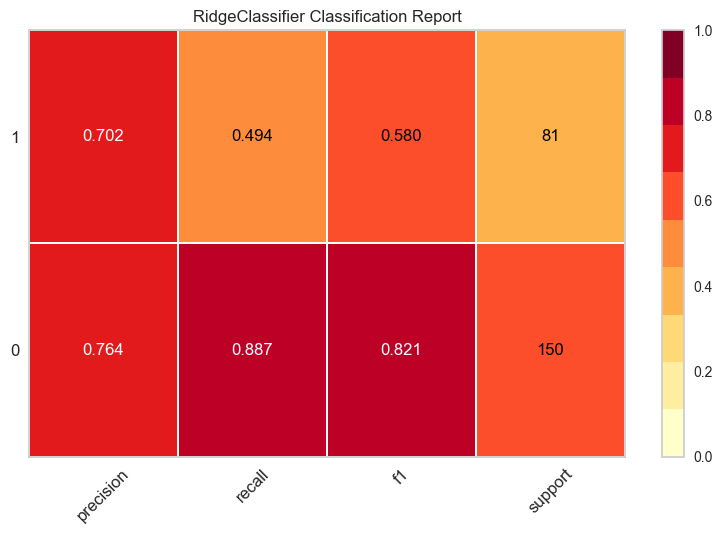

In [76]:
# plot class report
plot_model(best, plot = 'class_report')

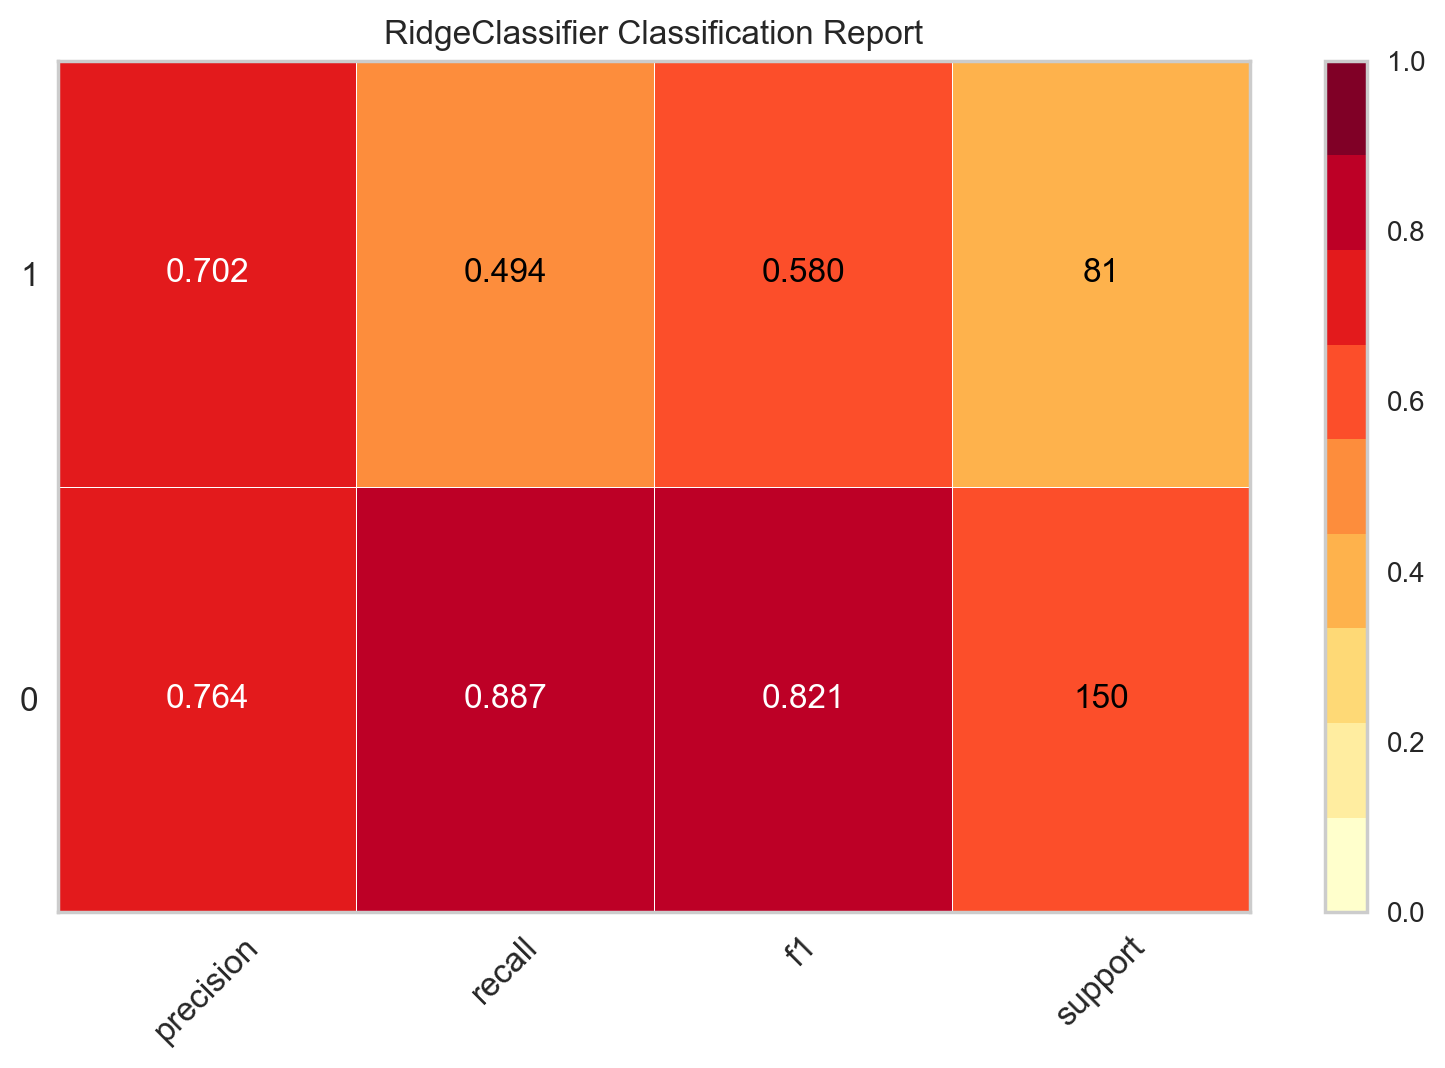

In [77]:
# to control the scale of plot
plot_model(best, plot = 'class_report', scale = 2)

In [78]:
# to save the plot
plot_model(best, plot = 'class_report', save=True)

'Class Report.png'

Some other parameters that you might find very useful in `plot_model` are:

- fit_kwargs
- plot_kwargs
- groups
- display_format

You can check the docstring of the function for more info.

In [79]:
# help(plot_model)